# multi_order_exemple

This notebook shows how to use `SolverV9` for an explicit multi-order nonlinear
spectroscopy calculation. The example computes a fifth-order double-quantum
(`chi5`, `2Q`) signal from a compact coupled two-mode model.

The workflow is intentionally explicit:

1. build a model Hamiltonian and interaction operator;
2. feed the model to `LiouvilleSpectroscopySolver`;
3. generate pathways from a phase-discrimination sequence;
4. define which interval is the NQ axis and which interval is detection;
5. pass all fixed times through `delays`;
6. calculate and plot pathway-resolved spectra.


## Imports

This example uses `SolverV9`, where the general pathway/protocol/delay API is
the main interface. No default `R1`-`R6` pathways are assumed by the solver.

The key imports are:

```python
from SolverV9 import LiouvilleSpectroscopySolver, SpectroscopyPlotter, standard_nq_protocol
```


In [1]:
from pathlib import Path

import numpy as np

from SolverV9 import (
    LiouvilleSpectroscopySolver,
    SpectroscopyPlotter,
    standard_nq_protocol,
)


### Coupled Two-Mode Model

This model describes two local transitions, labeled **h** and **l**, coupled through an excitonic interaction.

- `omega_h`, `omega_l`: Local transition energies in eV.
- `J`: Coupling between the two modes. It mixes the local states and produces delocalized eigenstates.
- `mu_h`, `mu_l`: Transition dipole amplitudes. Their squares approximately determine the relative oscillator strengths.
- `kappa`: Relaxation or dissipation rate included in the dynamics.
- `U_hh`, `U_ll`: Anharmonicities associated with two excitations occupying mode **h** or **l**, respectively.
- `U_hl`: Cross-interaction between one excitation on mode **h** and one on mode **l**.
- `max_manifold`: Maximum number of excitations included in the Hilbert space. A value of `3` includes up to the triply excited manifold.

Here, the negative anharmonicities `U_hh = U_ll = -0.020 eV` lower the energies of double excitations on the same mode, while `U_hl = 0.030 eV` raises the energy of states containing excitations on both modes.

### Solver Parameters

- `T`: System temperature. `T = 0` assumes that the system initially occupies its ground state.
- `Eta`: Homogeneous broadening used in the resolvents, in eV. It primarily controls the spectral linewidth.
- `backend`: Numerical implementation used by the solver. `"dense"` uses dense matrices and NumPy linear-algebra routines.

## Model parameters

The model is deliberately small: two bosonic optical modes with anharmonicities,
coupling, oscillator strengths, and a simple decay rate. The solver itself does
not depend on this particular model. For another system, replace the model
builder as long as it returns:

- `H`: Hamiltonian matrix;
- `mu`: light-matter interaction operator;
- `c_ops`: optional collapse operators;
- `rho0`: initial density matrix.

`max_manifold` controls how many excitation manifolds are included in the model
Hilbert space. A `2Q` fifth-order example needs access to doubly excited states,
so the model must include at least two excitations.


In [2]:
model_params = {
    "omega_h": 1.53,
    "omega_l": 1.58,
    "J": 0.010,
    "mu_h": 1.0,
    "mu_l": 0.3,
    "kappa": 0.001,
    "U_hh": -0.020,
    "U_ll": -0.020,
    "U_hl": 0.03,
    "max_manifold": 3,
}

solver_params = {
    "T": 0.0,
    "Eta": 0.005,
    "backend": "dense",
    "parallel_backend": "threading",
    "n_jobs": -1,
}


## Model builder

This function constructs the Hilbert basis, Hamiltonian, interaction operator,
collapse operators, and initial state. The construction details are model
specific; the important solver-facing convention is the returned tuple:

```python
H, mu, c_ops, rho0, basis
```

`feed_model(...)` will diagonalize `H`, split the interaction operator into
raising/lowering parts, and build the Liouville-space backend.


In [3]:
def build_bosonic_triexciton_model(params):
    maximum_manifold = int(params["max_manifold"])
    basis = tuple(
        (n_h, total - n_h)
        for total in range(maximum_manifold + 1)
        for n_h in range(total, -1, -1)
    )
    index = {state: i for i, state in enumerate(basis)}

    b_h = np.zeros((len(basis), len(basis)), dtype=complex)
    b_l = np.zeros_like(b_h)
    for upper_index, (n_h_value, n_l_value) in enumerate(basis):
        if n_h_value:
            b_h[index[(n_h_value - 1, n_l_value)], upper_index] = np.sqrt(
                n_h_value
            )
        if n_l_value:
            b_l[index[(n_h_value, n_l_value - 1)], upper_index] = np.sqrt(
                n_l_value
            )

    n_h = b_h.conj().T @ b_h
    n_l = b_l.conj().T @ b_l
    identity = np.eye(len(basis))
    H = (
        params["omega_h"] * n_h
        + params["omega_l"] * n_l
        + params["J"] * (b_h.conj().T @ b_l + b_l.conj().T @ b_h)
        + 0.5 * params["U_hh"] * n_h @ (n_h - identity)
        + 0.5 * params["U_ll"] * n_l @ (n_l - identity)
        + params["U_hl"] * n_h @ n_l
    )
    mu = (
        params["mu_h"] * (b_h + b_h.conj().T)
        + params["mu_l"] * (b_l + b_l.conj().T)
    )
    c_ops = [(b_h, params["kappa"]), (b_l, params["kappa"])]
    rho0 = np.zeros_like(H)
    rho0[0, 0] = 1.0
    return H, mu, c_ops, rho0, basis


## Feed the model to SolverV9

`LiouvilleSpectroscopySolver.feed_model(...)` prepares the dense Liouville
operators. Here `rho0` is supplied in the original model/site basis, so
`density_matrix_basis="site"` is used.


In [4]:
H, mu, c_ops, rho0, basis = build_bosonic_triexciton_model(model_params)
solver = LiouvilleSpectroscopySolver(solver_params)
solver.feed_model(
    H,
    mu,
    c_ops_raw=c_ops,
    initial_density_matrix=rho0,
    density_matrix_basis="site",
)



print("Basis size:", len(basis))


--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
Basis size: 10


### Example: Fifth-Order Double-Quantum Signal

This example generates the Liouville pathways contributing to a fifth-order (`χ⁽⁵⁾`) double-quantum (`2Q`) signal.

#### Pathway generation

- `"--+++"`: Phase-matching signature of the five field interactions. The first two interactions use the negative-frequency field component, while the last three use the positive-frequency component.
- `maximum_manifold=2`: Pathways may access states containing at most two excitations. This allows the doubly excited manifold required for a `2Q` coherence.
- `component="chi5_2q"`: Label assigned to this fifth-order double-quantum contribution.

#### Spectroscopy protocol

- `n_interactions=5`: Five light-matter interactions are applied, corresponding to a `χ⁽⁵⁾` response.
- `order=2`: Only pathways containing a second-order coherence, `|q| = 2`, are selected.
- `nq_interval=2`: The `2Q` coherence is required during the second evolution interval, after the second interaction. This interval is Fourier transformed along `omega_2q`.
- `detection_interval=5`: The emitted coherence is evaluated after the fifth and final interaction. This interval is Fourier transformed along `omega_emit`.
- `nq_axis="omega_2q"`: Name of the double-quantum frequency axis.
- `detection_axis="omega_emit"`: Name of the emission-frequency axis.


## Pathway generation and NQ protocol

The phase-discrimination string `"--+++"` contains five light-matter
interactions, so this is a fifth-order (`chi5`) calculation. `UFSS` generates the
allowed diagrams for this phase condition, and `SolverV9` translates those
diagrams into explicit `FrequencyPathway` objects.

The protocol declares how the propagation intervals are treated:

- `order=2`: select double-quantum coherence;
- `nq_interval=2`: the second interval is Fourier transformed as the `2Q` axis;
- `detection_interval=5`: the fifth interval is the emission/detection axis;
- `n_interactions=5`: fifth-order response;
- all other intervals are fixed time delays supplied later through `delays`.

The `component` label is arbitrary metadata used for grouping totals in the
result.


In [5]:
pathways = solver.generate_pathways_with_ufss(
    "--+++",
    maximum_manifold=2,
    component="chi5_2q",
)

protocol = standard_nq_protocol(
    order=2,
    nq_interval=2,
    detection_interval=5,
    n_interactions=5,
    nq_axis="omega_2q",
    detection_axis="omega_emit",
)

[(pathway.name, pathway.interactions, pathway.coherence_orders) for pathway in pathways]


[('P1', ('Bu', 'Bu', 'Ku', 'Ku', 'Bd'), (-1, -2, -1, 0, 1)),
 ('P2', ('Bu', 'Bu', 'Ku', 'Bd', 'Ku'), (-1, -2, -1, 0, 1)),
 ('P3', ('Bu', 'Bu', 'Ku', 'Bd', 'Bd'), (-1, -2, -1, 0, 1)),
 ('P4', ('Bu', 'Bu', 'Bd', 'Ku', 'Ku'), (-1, -2, -1, 0, 1)),
 ('P5', ('Bu', 'Bu', 'Bd', 'Ku', 'Bd'), (-1, -2, -1, 0, 1)),
 ('P6', ('Bu', 'Bu', 'Bd', 'Bd', 'Ku'), (-1, -2, -1, 0, 1))]

## Frequency axes and fixed delays

The names in `axes={...}` must match the two frequency interval names in the
protocol: here `omega_2q` and `omega_emit`.

Every time-domain interval in the protocol must appear in `delays`. For this
fifth-order protocol, `protocol.time_interval_names` returns `("t1", "t3",
"t4")`: the second interval is not a delay because it is the `2Q` frequency
axis.

To study dynamics, change one or more entries in `delays`, for example
`delays["t3"] = 50.0`, and rerun the spectrum.


In [6]:
omega_2q = np.linspace(-3.20, -2.80, 150)
omega_emit = np.linspace(1.38, 1.68, 150)


delays = {
    "t1": 3.0,
    "t3": 3.0,
    "t4": 3.0
}


result = solver.generate_NQ_spectrum(
    2,
    protocol,
    axes={"omega_2q": omega_2q, "omega_emit": omega_emit},
    delays=delays,
    pathways=pathways,
    parallel_backend=solver_params.get("parallel_backend", "serial"),
    n_jobs=solver_params.get("n_jobs", 1),
)


Calculating 6 pathway spectrum/s on a 150x150 grid with protocol 'standard_2q' using parallel=threading, n_jobs=-1.
Using dense prefix-tree pathway reuse.


### Plotting Parameters

This block uses the contour plotting helper from `SpectroscopyPlotter`. It reads the `SpectrumResult` returned by `solver.generate_NQ_spectrum(...)` and plots each selected pathway as real, imaginary, and absolute-value panels.

- `spectra="pathways"`: plots individual pathway spectra from `result.pathways`.
- `names=None`: uses all pathway names returned by the solver. Replace by a list such as `["P1", "P2"]` to plot only selected pathways.
- `totals="selected"`: adds the sum of the selected pathways.
- `normalization="panel"`: normalizes each displayed panel independently. This emphasizes line shapes but does not preserve relative amplitudes between panels. Use `"row"` or `"none"` when relative amplitudes matter.
- `color_map="Spectral_r"` and `levels=12`: control the contour style.
- `save_pdf=False`: keeps the GitHub example from writing files by default. Set it to `True` to save the contour figure.


## Plot pathway-resolved spectra with contour panels

`plot_spectrum_result_contours(...)` is the recommended compact plotting function for this notebook. It wraps `plot_contourf_multi_spectra(...)` and automatically extracts axes, pathway spectra, and optional totals from the `SpectrumResult`.

For component totals instead of individual pathways, use `spectra="components"` and choose names from `result.components`, for example `"+2Q"`, `"-2Q"`, or `"2Q"` depending on the generated protocol and selected pathways.


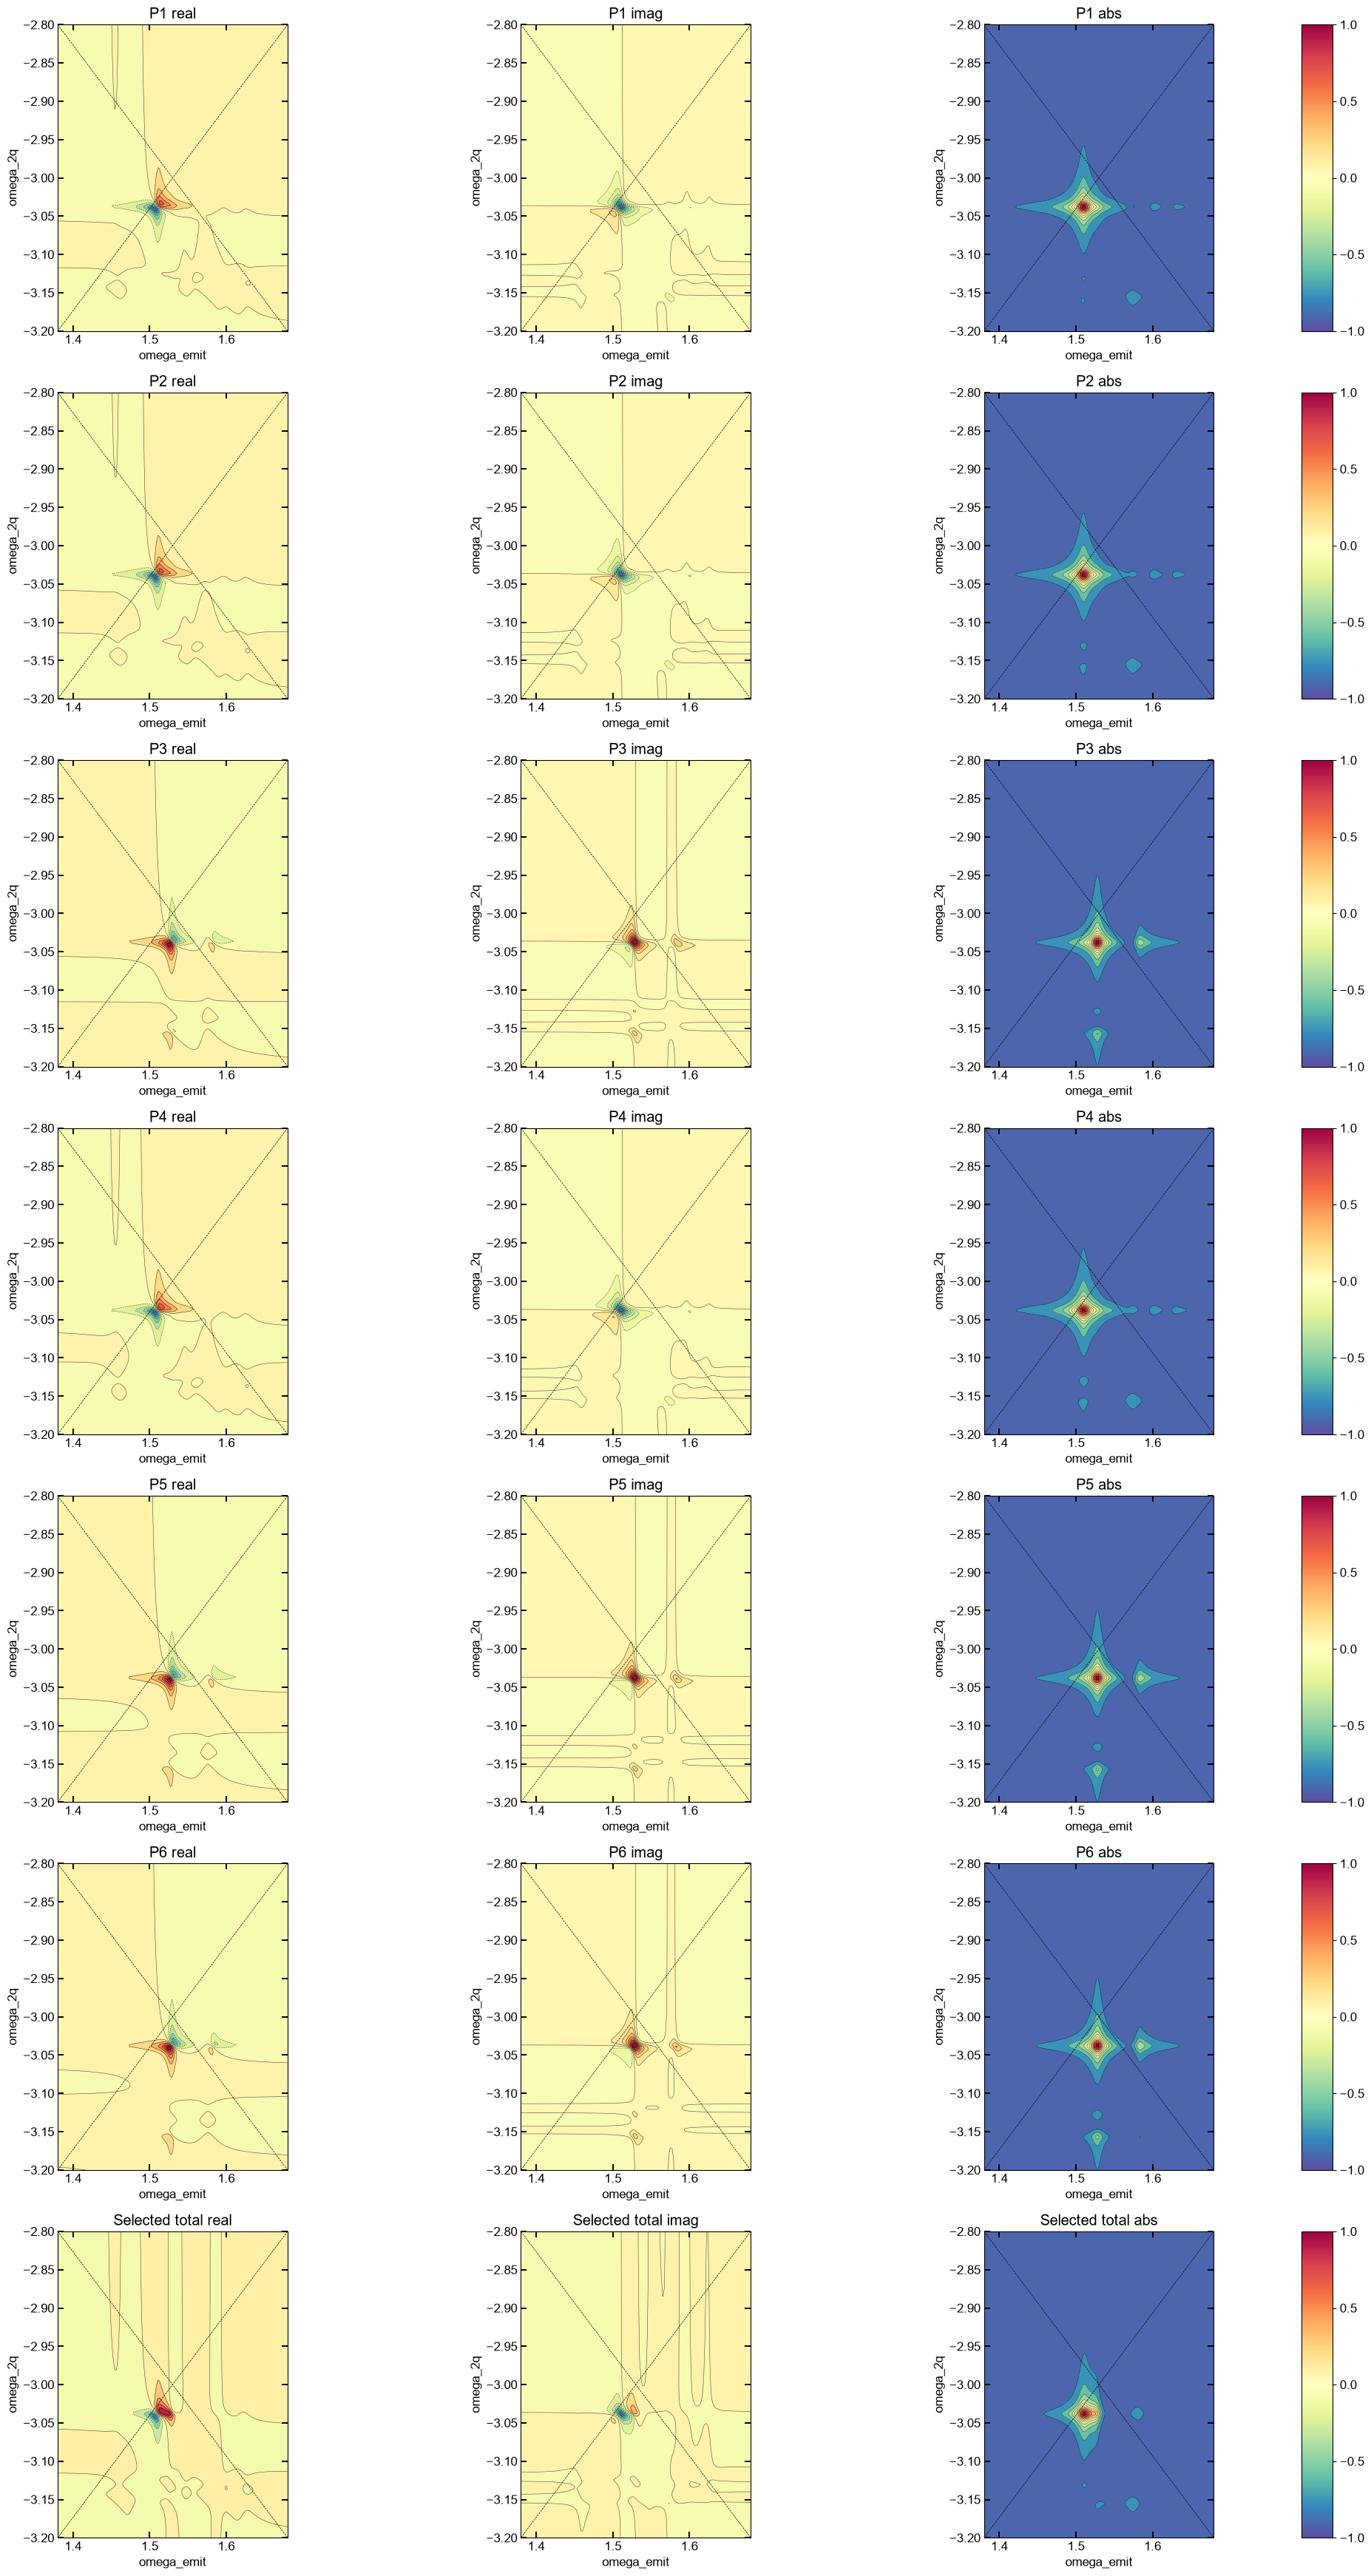

In [7]:
save_pdf = False
output_directory = Path.cwd() / "Result_Test" / "Multiorder_pathway_plot"
spectrum_pdf_path = output_directory / "chi5_Q2_pathways_ULL_m0_02_UHH_m0_02_UHL_0_03.pdf"

if save_pdf:
    output_directory.mkdir(parents=True, exist_ok=True)

plotter = SpectroscopyPlotter(detection_phase=0)
fig, axes = plotter.plot_spectrum_result_contours(
    result,
    spectra="pathways",
    names=None,
    totals="selected",
    normalization="panel",
    color_map="Spectral_r",
    levels=12,
    contour_lines=True,
    save_path=spectrum_pdf_path if save_pdf else None,
    show=True,
)


## Returned objects

`plot_spectrum_result_contours(...)` returns the Matplotlib `fig` and `axes`. The numerical data remain in `result`:

- `result.pathways`: one complex matrix per pathway;
- `result.components`: component totals, including `+2Q`, `-2Q`, and `2Q` when available;
- `result.axis_names` and `result.axis_values`: axis metadata;
- `result.pathway_metadata`: pathway provenance and coherence histories.


In [8]:
print("Pathway panels:", list(result.pathways))
print("Component totals:", list(result.components))
print("Axis names:", result.axis_names)
if save_pdf:
    print("Spectrum PDF:", spectrum_pdf_path)


Pathway panels: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
Component totals: ['chi5_2q', '+2Q', '-2Q', '2Q']
Axis names: ('omega_2q', 'omega_emit')
